In [8]:
pip install bruges

Note: you may need to restart the kernel to use updated packages.


In [1]:
import bruges as bg
import matplotlib.pyplot as plt
w,t=bg.filters.ormsby(duration=0.256,dt=0.002,f=[5,10,40,80])

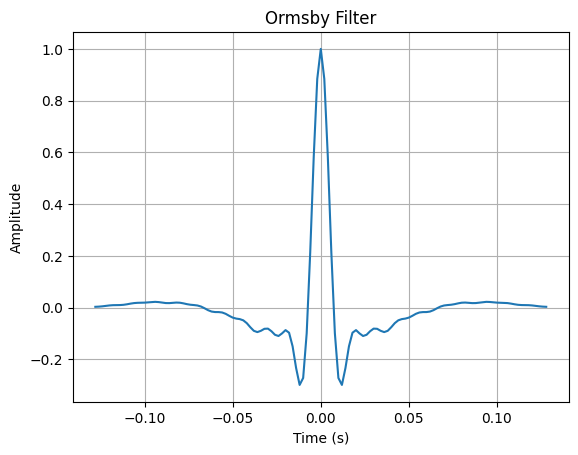

In [10]:
plt.plot(t,w)   
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Ormsby Filter')
plt.grid()
plt.show()

# Make a wedge using bruges

The wedge function in models submodule allows you to generate a variety of stratigraphic geometries. The default gives us a model m which is a 2-D NumPy array of size (100, 100). It has 3 layers in it.

In [2]:
import bruges as bg
import matplotlib.pyplot as plt
import numpy as np

m,top,base,ref=bg.models.wedge(width=1000)

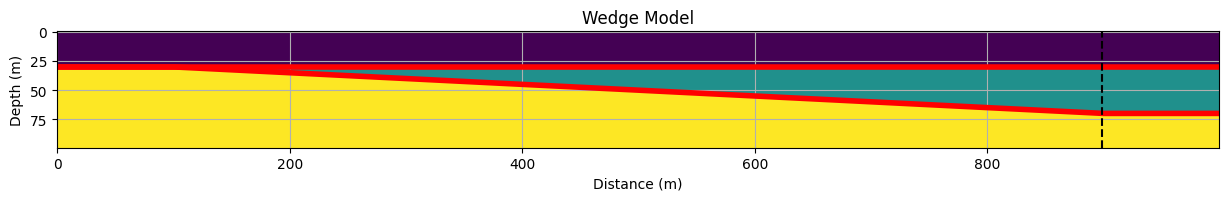

In [3]:
plt.figure(figsize=(15,15))
plt.imshow(m)
plt.plot(top,"r",lw=4)
plt.plot(base,"r",lw=4)
plt.axvline(ref,color='k',ls='--')
plt.xlabel('Distance (m)')
plt.ylabel('Depth (m)')
plt.title('Wedge Model')
plt.grid()
plt.show()

## Make an earth

In [4]:
vps=np.array([2000,2500,3000,3500,4000])
vss=np.array([1000,1500,2000,2500,3000])
rhos=np.array([2000,2200,2400,2600,2800])

In [5]:
vp=vps[m]
vs=vss[m]
rho=rhos[m]

In [6]:
print("P-wave velocity (m/s):\n", vp)
print("S-wave velocity (m/s):\n", vs)
print("Density (kg/m^3):\n", rho)

P-wave velocity (m/s):
 [[2000 2000 2000 ... 2000 2000 2000]
 [2000 2000 2000 ... 2000 2000 2000]
 [2000 2000 2000 ... 2000 2000 2000]
 ...
 [3000 3000 3000 ... 3000 3000 3000]
 [3000 3000 3000 ... 3000 3000 3000]
 [3000 3000 3000 ... 3000 3000 3000]]
S-wave velocity (m/s):
 [[1000 1000 1000 ... 1000 1000 1000]
 [1000 1000 1000 ... 1000 1000 1000]
 [1000 1000 1000 ... 1000 1000 1000]
 ...
 [2000 2000 2000 ... 2000 2000 2000]
 [2000 2000 2000 ... 2000 2000 2000]
 [2000 2000 2000 ... 2000 2000 2000]]
Density (kg/m^3):
 [[2000 2000 2000 ... 2000 2000 2000]
 [2000 2000 2000 ... 2000 2000 2000]
 [2000 2000 2000 ... 2000 2000 2000]
 ...
 [2400 2400 2400 ... 2400 2400 2400]
 [2400 2400 2400 ... 2400 2400 2400]
 [2400 2400 2400 ... 2400 2400 2400]]


In [7]:
# Calculate acoustic impedance
ai=vp*rho
print("Acoustic Impedance (kg/m^2/s):\n", ai)

Acoustic Impedance (kg/m^2/s):
 [[4000000 4000000 4000000 ... 4000000 4000000 4000000]
 [4000000 4000000 4000000 ... 4000000 4000000 4000000]
 [4000000 4000000 4000000 ... 4000000 4000000 4000000]
 ...
 [7200000 7200000 7200000 ... 7200000 7200000 7200000]
 [7200000 7200000 7200000 ... 7200000 7200000 7200000]
 [7200000 7200000 7200000 ... 7200000 7200000 7200000]]


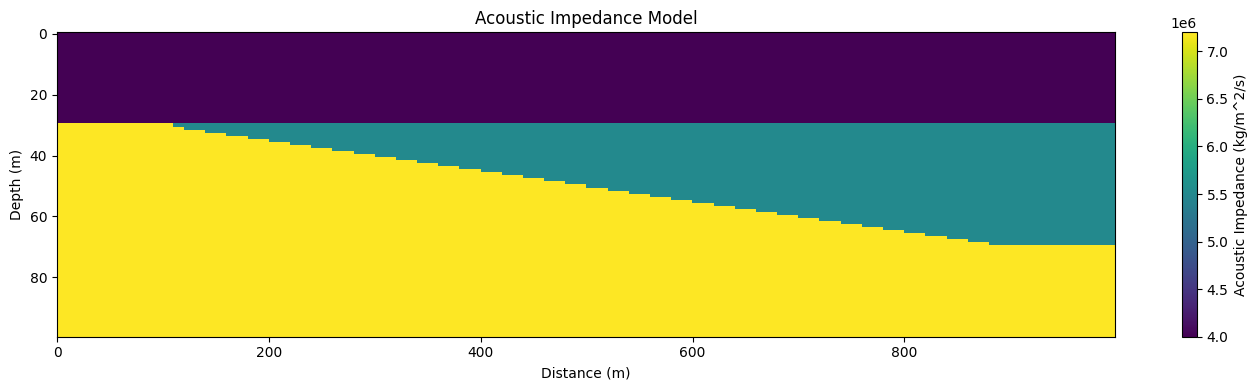

In [8]:
plt.figure(figsize=(14,4))  # wide figure

plt.imshow(ai, interpolation='none', aspect='auto')
plt.colorbar(label='Acoustic Impedance (kg/m^2/s)')

plt.title('Acoustic Impedance Model')
plt.xlabel('Distance (m)')
plt.ylabel('Depth (m)')

plt.tight_layout()
plt.show()

## Acoustic reflectivity
We don’t actually need impedance, we need reflectivity. We can use bruges to create a section of normal incidence reflection coefficient; this will be what we convolve with a wavelet.

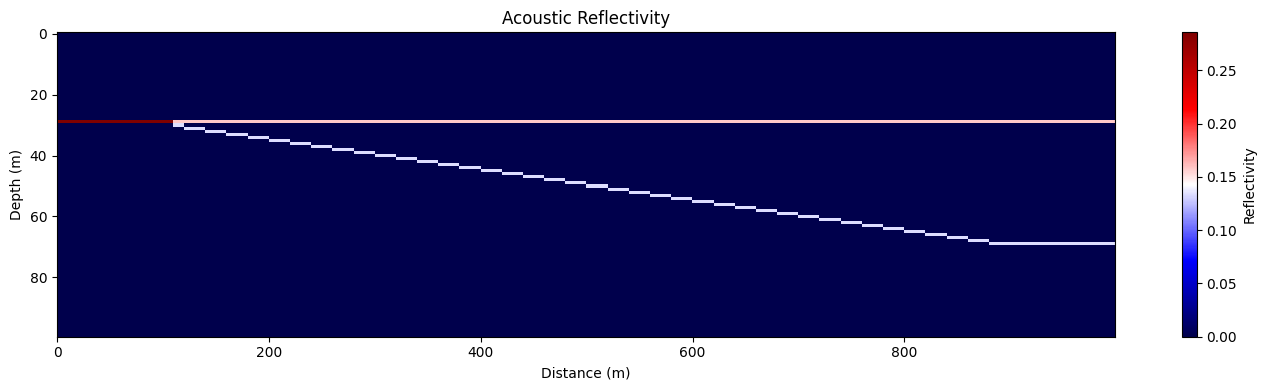

In [9]:
reflectivity_Series=bg.reflection.acoustic_reflectivity(vp,rho)
plt.figure(figsize=(14,4))  # wide figure
plt.imshow(reflectivity_Series, interpolation='none', aspect='auto', cmap='seismic')
plt.colorbar(label='Reflectivity')
plt.title('Acoustic Reflectivity')
plt.xlabel('Distance (m)')
plt.ylabel('Depth (m)')
plt.tight_layout()
plt.show()

Offset reflectivity

We can also calculate the exact Zoeppritz offset reflectivity. For example, to compute the reflectivity at 10 degrees of offse

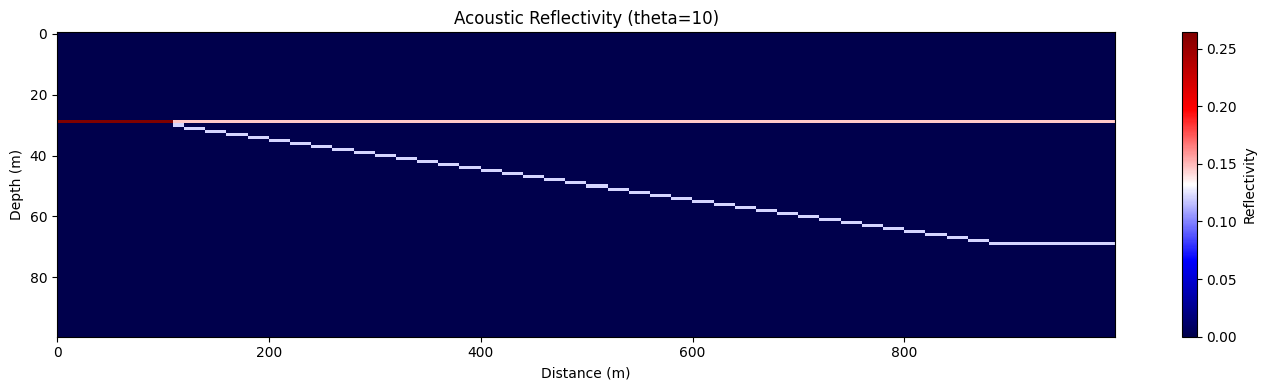

In [10]:
rc_10 = bg.reflection.reflectivity(vp, vs, rho, theta=10)

plt.figure(figsize=(14,4))  # wide figure
plt.imshow(rc_10.real, interpolation='none', aspect='auto', cmap='seismic')
plt.colorbar(label='Reflectivity')
plt.title('Acoustic Reflectivity (theta=10)')
plt.xlabel('Distance (m)')
plt.ylabel('Depth (m)')
plt.tight_layout()
plt.show()

In [11]:
rc=bg.reflection.reflectivity(vp,vs,rho,theta=np.arange(60),method="shuey")
rc.shape

(60, 100, 1000)

The 10-degree reflectivity we computed before is in there as rc[10], but we can also see how reflectivity varies with angle:

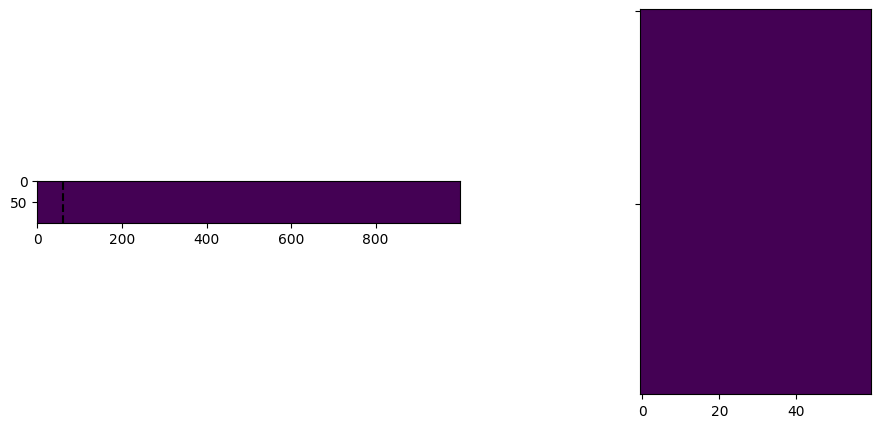

In [12]:
offset=10 #degree
trace=60
fig,axs=plt.subplots(ncols=2,figsize=(12,5),sharey=True)
axs[0].imshow(rc[offset].real,vmin=0.01,vmax=0.01)
axs[0].axvline(trace,c="k",ls="--")
axs[1].imshow(rc[:,:,trace].real.T,vmin=0.01,vmax=0.01)



plt.show()

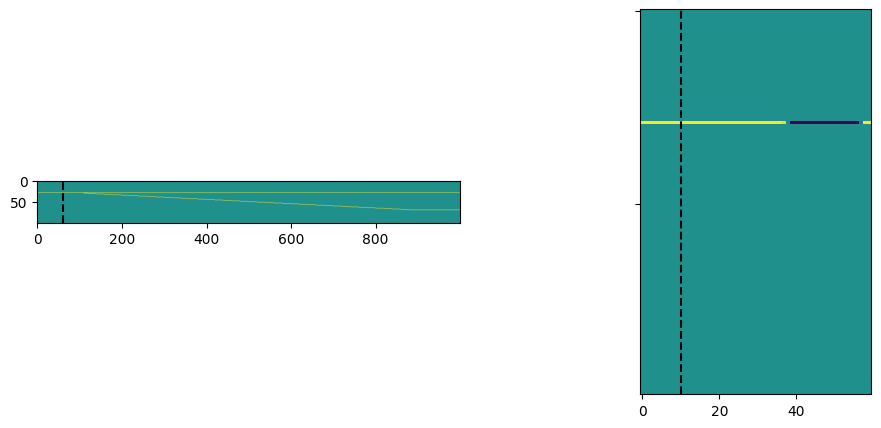

In [13]:
offset = 10  # degrees
trace = 60

fig, axs = plt.subplots(ncols=2, figsize=(12, 5), sharey=True)
axs[0].imshow(rc[offset].real, vmin=-0.01, vmax=0.01)
axs[0].axvline(trace, c='k', ls='--')
axs[1].imshow(rc[:, :, trace].real.T, vmin=-0.01, vmax=0.01)
axs[1].axvline(offset, c='k', ls='--')
plt.show()

## A 1D wavelet

Ricker wavelet

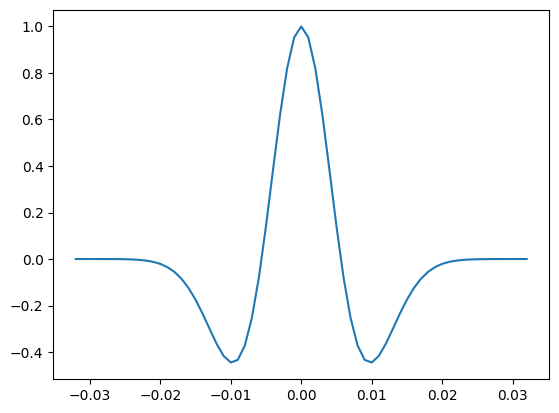

In [14]:
w,t=bg.filters.ricker(0.064,0.001,40)
plt.plot(t,w)

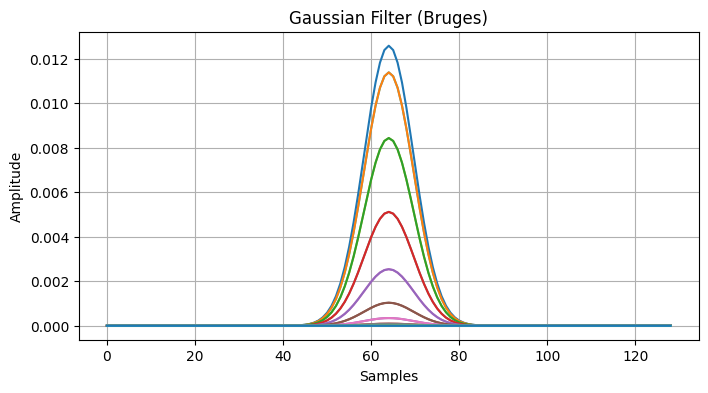

In [15]:
import bruges as bg
import numpy as np
import matplotlib.pyplot as plt

size = 64

w = bg.filters.gaussian(size, 10)

t = np.arange(len(w))

plt.figure(figsize=(8,4))
plt.plot(t, w)
plt.title("Gaussian Filter (Bruges)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

### 2D Wavelet bank

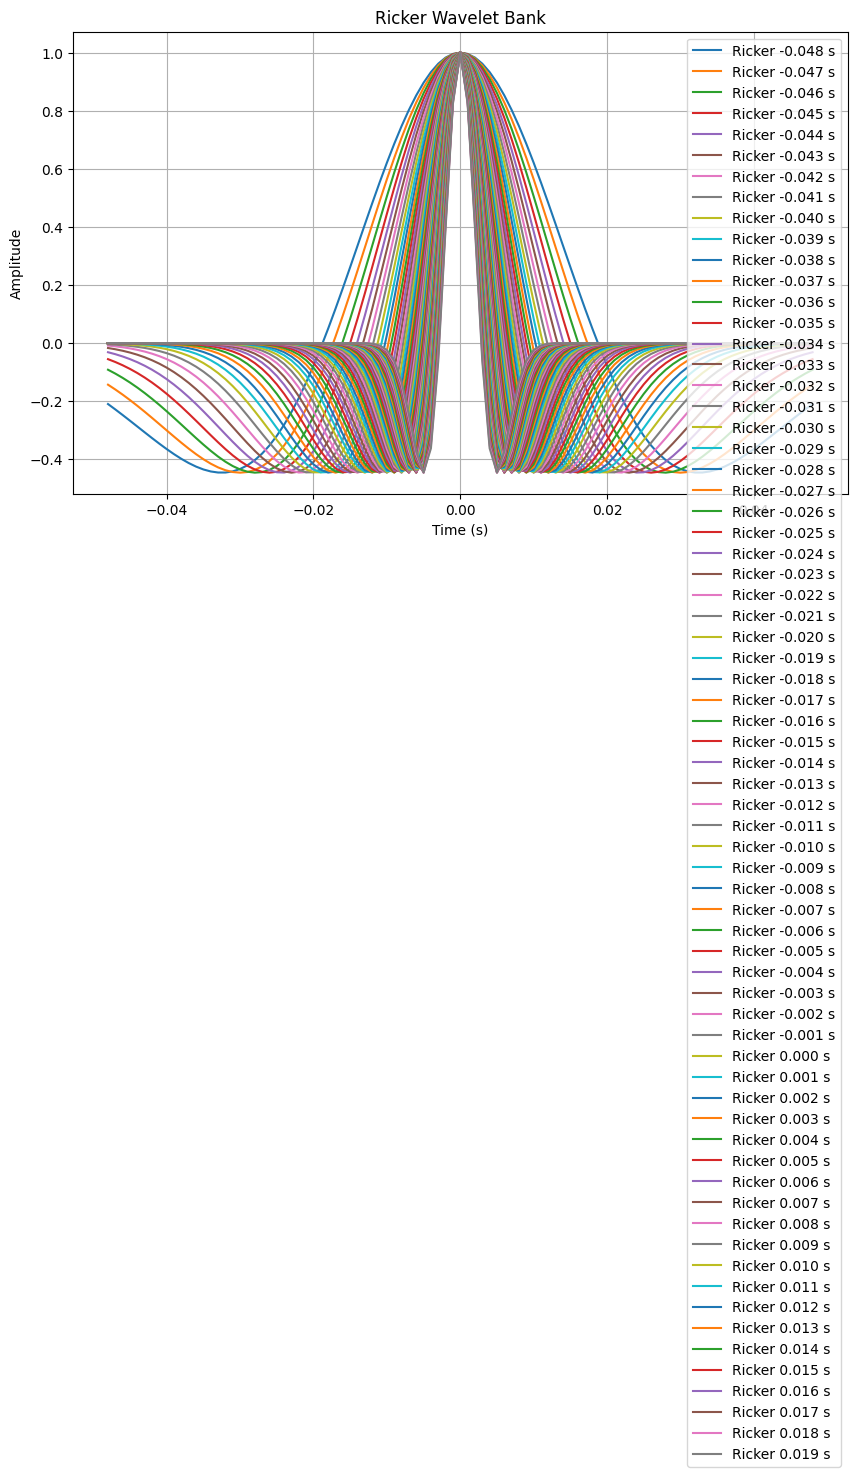

In [16]:
w_bank,t= bg.filters.ricker(0.096,0.001,np.arange(12,80))
plt.figure(figsize=(10,6))
for i in range(w_bank.shape[0]):
    plt.plot(t,w_bank[i],label=f'Ricker {t[i]:.3f} s')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Ricker Wavelet Bank')
plt.legend()
plt.grid()
plt.show()

In [17]:
w_bank.shape

(68, 97)

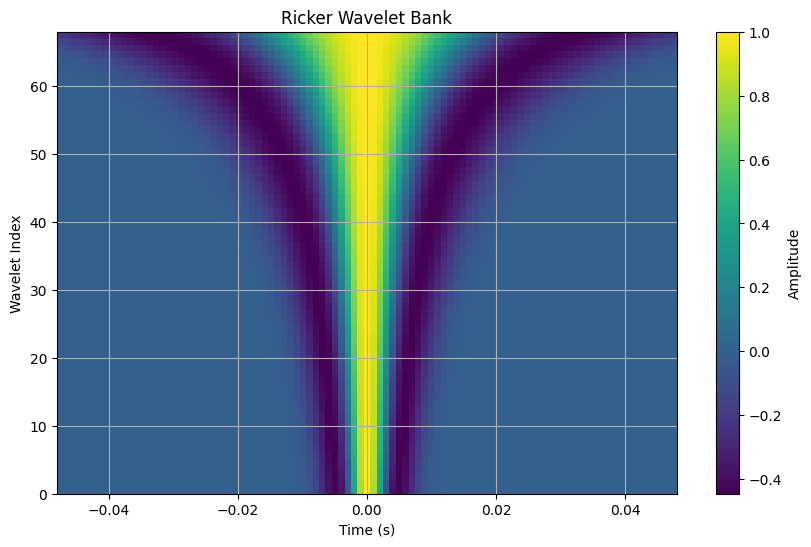

In [18]:
w_bank,t=bg.filters.ricker(duration=0.096,dt=0.001,f=np.arange(12,80))
plt.figure(figsize=(10,6))
plt.imshow(w_bank, aspect='auto', extent=[t[0], t[-1], 0, w_bank.shape[0]])
plt.colorbar(label='Amplitude')
plt.xlabel('Time (s)')
plt.ylabel('Wavelet Index')
plt.title('Ricker Wavelet Bank')
plt.grid()
plt.show()


## A 1D Convolution

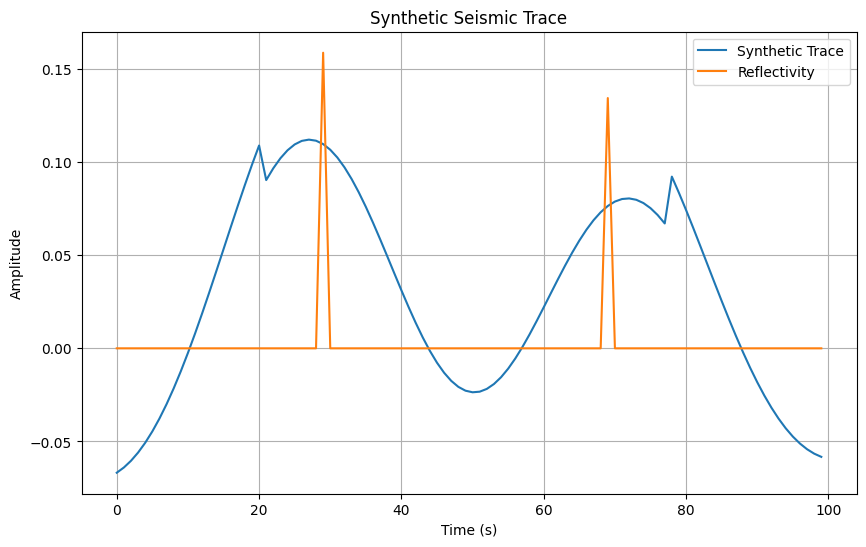

In [19]:
rc_ref=rc[0,:,ref]
syn=bg.filters.convolve(rc_ref,w_bank[0],axis=0)
plt.figure(figsize=(10,6))
plt.plot(syn, label='Synthetic Trace')
plt.plot(rc_ref, label='Reflectivity')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Synthetic Seismic Trace')
plt.legend()
plt.grid()
plt.show()

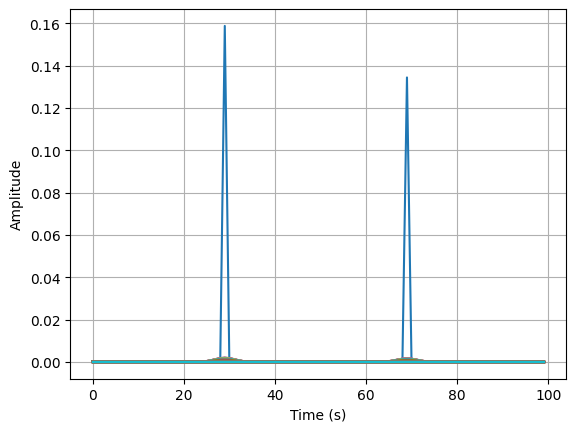

In [20]:
rc_ref=rc[0,:,ref]
syn=bg.filters.convolve(rc_ref,w)
plt.plot(rc_ref)    
plt.plot(syn)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.show() 

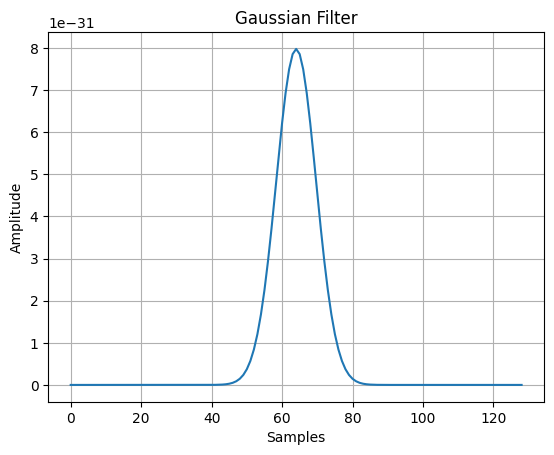

In [25]:
import bruges as bg
import numpy as np
import matplotlib.pyplot as plt

size = 64

w = bg.filters.gaussian(size)   # no std argument
w = w[:,0]                      # take one filter column

t = np.arange(len(w))

plt.plot(t, w)
plt.title("Gaussian Filter")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

In [29]:

print(w.shape)

syn = np.convolve(rc_ref, w, mode='same')

(129,)


In [30]:
print(rc_ref.shape)
print(w.shape)

(100,)
(129,)


In [31]:
w, t = bg.filters.ricker(duration=0.064, dt=0.001, f=40)

syn = np.convolve(rc_ref, w, mode='same')

### 2D COnvolution

In [32]:
syn=bg.filters.convolve(rc,w,axis=1)


In [33]:
syn.shape

(60, 100, 1000)

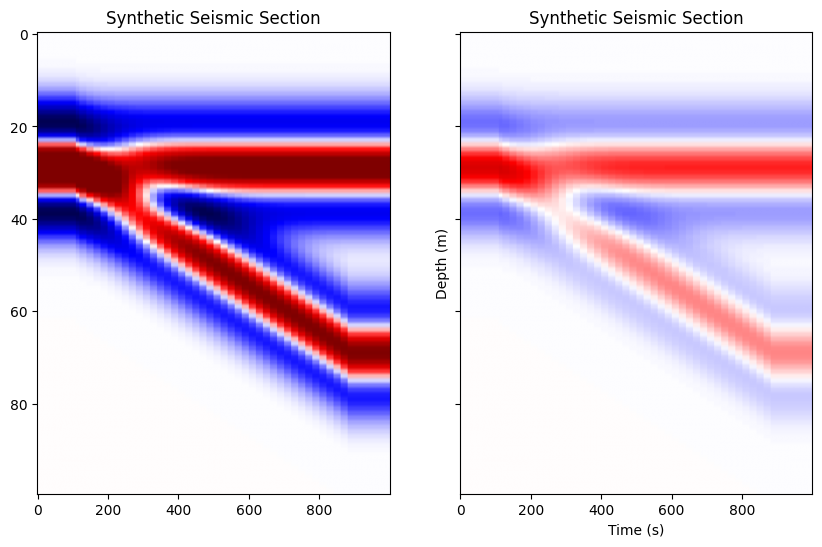

In [46]:
ma=np.percentile(syn, 99)
near,far=0,30
fig,axs=plt.subplots(ncols=2,figsize=(10,6),sharey=True)
axs[0].imshow(syn[near], cmap="seismic",vmin=-ma, vmax=ma,aspect='auto')
axs[1].imshow(syn[far], cmap="seismic",vmin=-ma, vmax=ma,aspect='auto')
plt.xlabel('Time (s)')
plt.ylabel('Depth (m)')
axs[0].set_title('Synthetic Seismic Section')
axs[1].set_title('Synthetic Seismic Section')
plt.show()

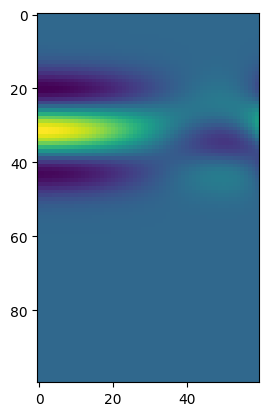

In [48]:
## Look at a singletrace and a single " angle gather"
trace=200
plt.imshow(syn[:,:,trace].T)

In [ ]:
syn=bg.filters.convolve(rc,w_bank,axis=1)
syn.shape

In [ ]:
plt.imshow(syn[10, 30])